In [ ]:
# Teil 2: Datenbeschreibung (Data Description)

In diesem Notebook befasse ich mich mit der Datenanalyse: Ich lade den Datensatz, wähle eine Zielvariable aus, berechne statistische Kennzahlen, erstelle eine Grafik und führe eine Skalierung der Merkmale durch.

In [8]:
try:
    import openpyxl
except ImportError:
    import sys
    !{sys.executable} -m pip install openpyxl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
data_path = "LB.xlsx"

try:
    df = pd.read_excel(data_path, engine="openpyxl")
    display(df.head())
    print("columns:", list(df.columns))
except Exception as e:
    print("Fehler beim Laden:", type(e).__name__, e)

exists: True
abs: c:\Users\pasca\OneDrive - BBBaden\IMS Baden\Modul 259\LB.xlsx
mode: 0o100666 size: 563742


,Lastname,Name,Team,Position,Games Played,Goals,Missed,Field Goals,Penalty Goals,Shooting Accuracy,Assists,Technical Faults,Steals,Blocks,Yellow Cards,2 Min Exclusion,Red Cards,Blue Cards,Season,Tier
0,Savvas,Savvas,HIL,LB,36,289,195,210,79,5971,52,40,7,7,20,16,1,0,17/18,B
1,Gunnarsson,Arnor Thor,BHC,RW,38,275,93,163,112,7473000000000001,14,17,11,0,2,3,0,0,17/18,B
2,Smits,Kay,WHV,RB,37,258,141,178,80,6466,90,74,20,4,5,10,0,0,17/18,B
3,Kaletsch,Paul,KON,LB,35,251,194,142,109,564,74,62,4,6,13,12,0,0,17/18,B
4,Billek,Florian,COB,RW,37,243,98,132,111,7126,24,29,20,0,4,2,0,0,17/18,B


columns: ['Lastname', 'Name', 'Team', 'Position', 'Games Played', 'Goals', 'Missed', 'Field Goals', 'Penalty Goals', 'Shooting Accuracy', 'Assists', 'Technical Faults', 'Steals', 'Blocks', 'Yellow Cards', '2 Min Exclusion', 'Red Cards', 'Blue Cards', 'Season', 'Tier']


## Zielvariable auswählen

In diesem Projekt soll **„Goals“ (Tore)** als Zielvariable verwendet werden. Wir möchten vorhersagen, wie viele Tore ein Spieler erreicht. Diese Größe ist wichtig, weil Tore den Spielerfolg widerspiegeln und durch verschiedene Faktoren beeinflusst werden. Beispiele sind die Anzahl gespielter Matches, die Rolle im Team, die Anzahl der Assists und technische Fehler. Daher wird „Goals“ als Zielgröße analysiert und später für Modellierung verwendet.

In dieser Analyse wird die Spalte **„Shooting Accuracy“** nicht verwendet, da sie im Datensatz unzuverlässige Werte enthält.

In [10]:
numeric_cols = [c for c in df.select_dtypes(include="number").columns if c != "Shooting Accuracy"]
numeric_cols

['Games Played',
 'Goals',
 'Missed',
 'Field Goals',
 'Penalty Goals',
 'Assists',
 'Technical Faults',
 'Steals',
 'Blocks',
 'Yellow Cards',
 '2 Min Exclusion',
 'Red Cards',
 'Blue Cards']

In [14]:
print("Zentrale Statistiken (Beschreibung):")
display(df[["Goals", "Games Played", "Assists"]].describe())

print("Goals (Tore):")
print("  Sum:", df["Goals"].sum())
print("  Median:", df["Goals"].median())
print("  Standardabweichung:", df["Goals"].std())

for col in ["Games Played", "Assists"]:
    if col in df:
        print(f"{col} - Median: {df[col].median():.2f}, Std: {df[col].std():.2f}")

Zentrale Statistiken (Beschreibung):


,Goals,Games Played,Assists
count,5825.000000,5825.000000,5825.000000
mean,42.555193,23.000172,15.416652
std,49.036178,12.135913,23.764671
min,0.000000,1.000000,0.000000
25%,1.000000,13.000000,1.000000
50%,25.000000,27.000000,5.000000
75%,69.000000,33.000000,18.000000
max,289.000000,38.000000,210.000000


Goals (Tore):
  Sum: 247884
  Median: 25.0
  Standardabweichung: 49.03617837960944
Games Played - Median: 27.00, Std: 12.14
Assists - Median: 5.00, Std: 23.76


## Grafik erstellen

Im Folgenden wird eine Scatterplot-Grafik erstellt, um mögliche Zusammenhänge zwischen zwei numerischen Variablen zu untersuchen.  
Passe `x_column` und `y_column` an, um für deinen Datensatz sinnvolle Felder auszuwählen.

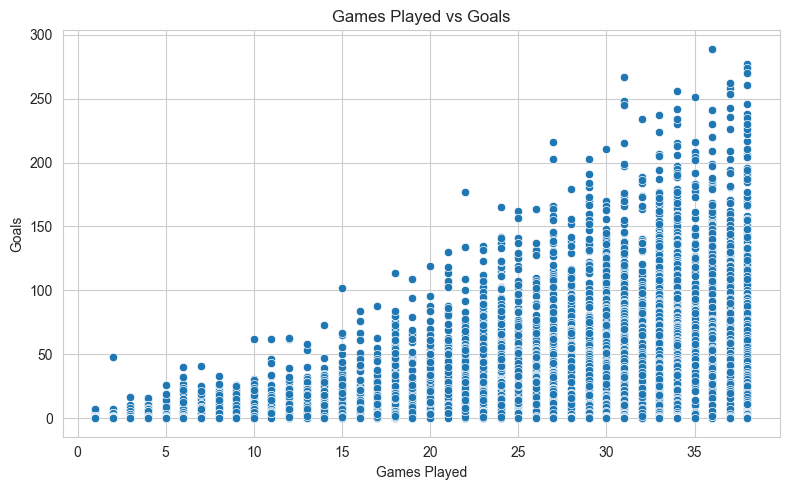

In [12]:
x_column = "Games Played"
y_column = "Goals"

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df[x_column], y=df[y_column])
plt.title(f"{x_column} vs {y_column}")
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.tight_layout()
plt.show()

## Skalierung der Daten

Hier wird eine Standard-Skalierung (z‑Score) angewendet, die später für viele Machine-Learning-Verfahren nützlich sein kann.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
if numeric_cols:
    df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])
df_scaled.head()

,Lastname,Name,Team,Position,Games Played,Goals,Missed,Field Goals,Penalty Goals,Shooting Accuracy,Assists,Technical Faults,Steals,Blocks,Yellow Cards,2 Min Exclusion,Red Cards,Blue Cards,Season,Tier
0,Savvas,Savvas,HIL,LB,1.071279,5.026207,5.182466,4.155498,4.725348,5971,1.539533,1.886605,0.886510,0.606274,4.039087,1.501559,1.124500,-0.062961,17/18,B
1,Gunnarsson,Arnor Thor,BHC,RW,1.236093,4.740679,2.042979,3.020427,6.821897,7473000000000001,-0.059617,0.349026,1.805766,-0.481025,-0.151434,-0.336077,-0.364185,-0.062961,17/18,B
2,Smits,Kay,WHV,RB,1.153686,4.393966,3.520385,3.382684,4.788880,6466,3.138682,4.159546,3.874092,0.140289,0.546986,0.653419,-0.364185,-0.062961,17/18,B
3,Kaletsch,Paul,KON,LB,0.988871,4.251202,5.151687,2.513268,6.631302,564,2.465356,3.357331,0.197068,0.450946,2.409440,0.936133,-0.364185,-0.062961,17/18,B
4,Billek,Florian,COB,RW,1.153686,4.088043,2.196875,2.271763,6.758366,7126,0.361212,1.151241,3.874092,-0.481025,0.314179,-0.477433,-0.364185,-0.062961,17/18,B


### Alternative: Keine Skalierung

Falls du später ein Modell verwendest, das nicht skalenempfindlich ist (z.B. Entscheidungsbaum / Random Forest),
kannst du eine der folgenden Erklärungen ergänzen:

> In diesem Datensatz wurde keine Skalierung durchgeführt, da die verwendeten Variablen bereits ähnliche Wertebereiche besitzen. Außerdem wird später ein Random-Forest-Modell verwendet, welches weniger empfindlich auf unterschiedliche Skalen reagiert.